<a href="https://colab.research.google.com/github/krishnabudhaniya-pixel/DS_Assignment_1/blob/main/International_Cricket_Council_(ICC).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##<b> The International Cricket Council (ICC) is the world governing body of cricket. It was founded as the Imperial Cricket Conference in 1909 by representatives from Australia, England and South Africa. It was renamed as the International Cricket Conference in 1965, and took up its current name in 1989. It organises world championship events such as Cricket World Cup, Women's Cricket World Cup, ICC T20 World Cup, ICC Women's T20 World Cup, ICC Champions Trophy and Under-19 Cricket World Cup.</b>

<br>

## <b> You recently got a lucky break in the field of Data Science. You got a job of Data Scientist at ICC. You are part of the Analytics Team which is involved in pre-match analyses, live-match analyses and post-match analyses. </b>

<br>

## <b>This data consists of 1417 T20 matches. Each row corresponds to a single T20 match. As a data scientist, you have to first explore the data and check its sanity. </b>

<br>

## <u><b>Further you are required to do some analyses :</b></u>
* ### Rename all the column names to their appropriate names, for example meta.created should be renamed as created_date
* ### Find out the top three venues which hosted the greatest number of matches.
* ### Find out the pair of cricket teams who played the most number of T20 matches against each other.
* ### Print the top five teams by their win percentages. Win percentage is defined as the number of matches won divided by the number of matches played and then multiplied by 100.
* ### Write a function to get the scorecard of each match. This function would take the innings value as argument and return two scorecard dataframes each for one team as shown below. So the first dataframe would contain the top 4 scorers of the team who batted first and the top 4 bowlers of the opponent team. And the second dataframe would contain the top 4 scorers of the team who batted second and the top 4 bowlers of the opponent team.




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('International_T20_Data.csv')

df.head()

,innings,meta.data_version,meta.created,meta.revision,info.dates,info.gender,info.match_type,info.outcome.by.wickets,info.outcome.winner,info.overs,info.player_of_match,info.teams,info.toss.decision,info.toss.winner,info.umpires,info.venue,info.city,info.outcome.by.runs,info.match_type_number,info.neutral_venue,info.outcome.method,info.outcome.result,info.outcome.eliminator,info.supersubs.New Zealand,info.supersubs.South Africa,info.bowl_out,info.outcome.bowl_out
0,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-18,2,"[datetime.date(2017, 2, 17)]",male,T20,5.0,Sri Lanka,20,['DAS Gunaratne'],"['Australia', 'Sri Lanka']",field,Sri Lanka,"['MD Martell', 'P Wilson']",Melbourne Cricket Ground,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-19,2,"[datetime.date(2017, 2, 19)]",male,T20,2.0,Sri Lanka,20,['DAS Gunaratne'],"['Australia', 'Sri Lanka']",field,Sri Lanka,"['SD Fry', 'SJ Nogajski']","Simonds Stadium, South Geelong",Victoria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-23,1,"[datetime.date(2017, 2, 22)]",male,T20,NaN,Australia,20,['A Zampa'],"['Australia', 'Sri Lanka']",field,Sri Lanka,"['MD Martell', 'P Wilson']",Adelaide Oval,NaN,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[{'1st innings': {'team': 'Hong Kong', 'delive...",0.9,2016-09-12,1,"[datetime.date(2016, 9, 5)]",male,T20,NaN,Hong Kong,20,NaN,"['Ireland', 'Hong Kong']",bat,Hong Kong,"['R Black', 'AJ Neill']","Bready Cricket Club, Magheramason",Londonderry,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"[{'1st innings': {'team': 'Zimbabwe', 'deliver...",0.9,2016-06-19,1,"[datetime.date(2016, 6, 18)]",male,T20,NaN,Zimbabwe,20,['E Chigumbura'],"['Zimbabwe', 'India']",field,India,"['TJ Matibiri', 'RB Tiffin']",Harare Sports Club,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Rename all the column names to their appropriate names, for example meta.created should be renamed as created_date

In [ ]:
df = df.rename(columns={
    'meta.created':'created_date',
    'meta.data_version':'data_version',
    'info.city':'city',
    'info.venue':'venue',
    'info.teams':'teams',
    'info.outcome.winner':'winner',
    'info.toss.winner':'toss_winner',
    'info.toss.decision':'toss_decision'
})

In [ ]:
df.columns
columns_table = pd.DataFrame(df.columns, columns=["Column Names"])

columns_table.index = columns_table.index + 1

columns_table

,Column Names
1,innings
2,data_version
3,created_date
4,meta.revision
5,info.dates
6,info.gender
7,info.match_type
8,info.outcome.by.wickets
9,winner
10,info.overs


Find out the top three venues which hosted the greatest number of matches.

In [ ]:
# get top 3 venues
top_venues = df['venue'].value_counts().head(3).reset_index()

# rename columns
top_venues.columns = ['Venue', 'Number_of_Matches']

# display table
top_venues

,Venue,Number_of_Matches
0,Dubai International Cricket Stadium,62
1,Sheikh Zayed Stadium,41
2,Shere Bangla National Stadium,39


/tmp/ipykernel_325/2344960716.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


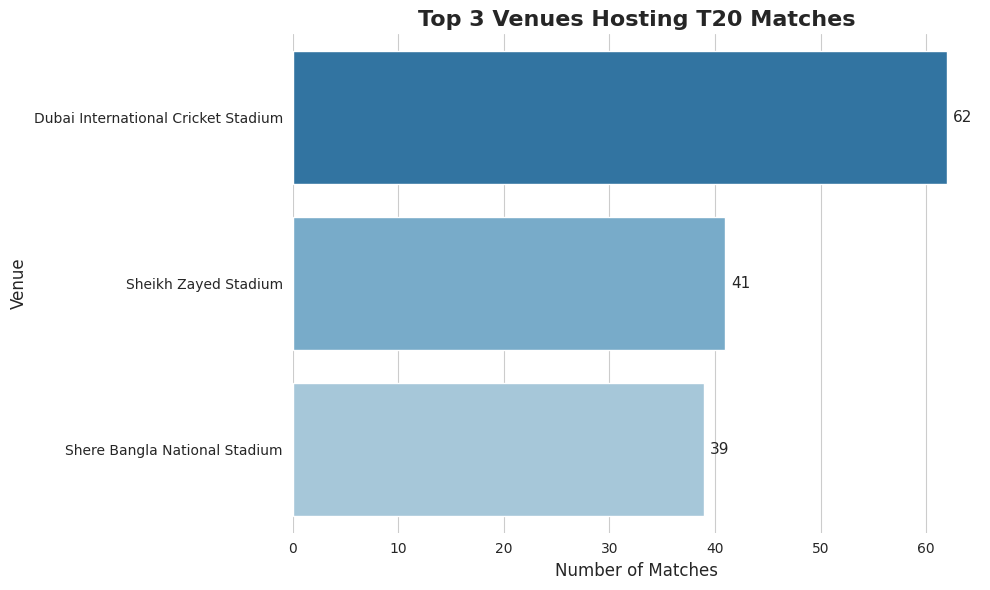

In [ ]:
plt.figure(figsize=(10,6))

sns.set_style("whitegrid")

# highlight top venue
colors = ["#1f77b4", "#6baed6", "#9ecae1"]

ax = sns.barplot(
    data=top_venues,
    x="Number_of_Matches",
    y="Venue",
    palette=colors
)

plt.title("Top 3 Venues Hosting T20 Matches", fontsize=16, weight="bold")
plt.xlabel("Number of Matches", fontsize=12)
plt.ylabel("Venue", fontsize=12)

# add values on bars
for i, v in enumerate(top_venues["Number_of_Matches"]):
    ax.text(v + 0.5, i, f"{v}", va='center', fontsize=11)

# cleaner look
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

Find out the pair of cricket teams who played the most number of T20 matches against each other.

In [ ]:
df['teams'] = df['teams'].str.replace('[', '', regex=False)\
                         .str.replace(']', '', regex=False)\
                         .str.replace("'", '', regex=False)

df[['team1','team2']] = df['teams'].str.split(',', expand=True)

df['team1'] = df['team1'].str.strip()
df['team2'] = df['team2'].str.strip()

df['team_pair'] = df.apply(lambda x: tuple(sorted([x['team1'], x['team2']])), axis=1)

pair_counts = df['team_pair'].value_counts()


In [ ]:
top_pairs = pair_counts.head(5).reset_index()

top_pairs.columns = ["Team Pair", "Matches Played"]

# convert tuple to string so seaborn can plot it
top_pairs["Team Pair"] = top_pairs["Team Pair"].astype(str)

top_pairs

,Team Pair,Matches Played
0,"('Australia', 'England')",45
1,"('Australia', 'Pakistan')",33
2,"('England', 'West Indies')",33
3,"('Australia', 'India')",32
4,"('England', 'Pakistan')",31


/tmp/ipykernel_325/366720968.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


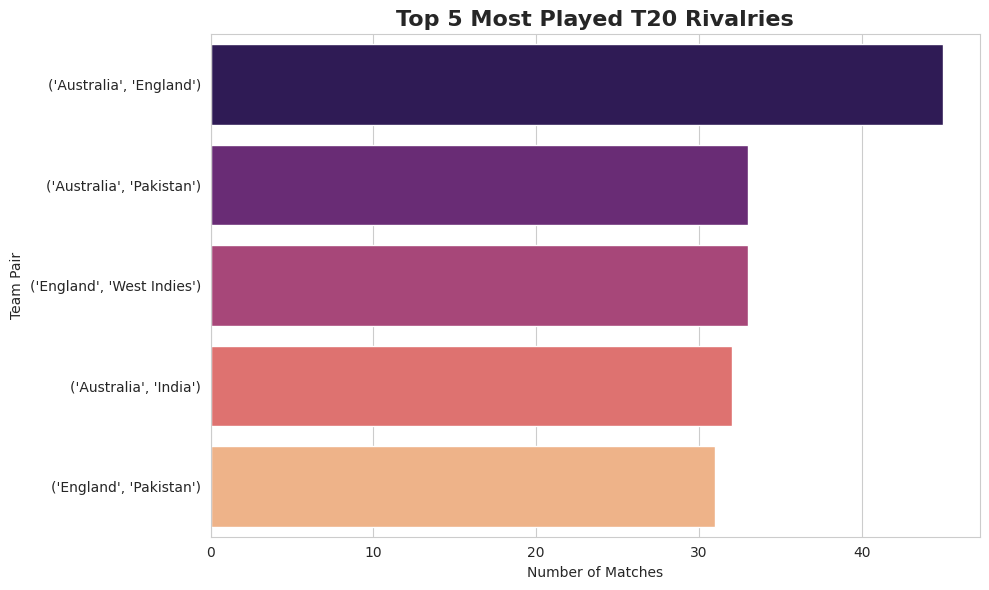

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_pairs,
    x="Matches Played",
    y="Team Pair",
    palette="magma"
)

plt.title("Top 5 Most Played T20 Rivalries", fontsize=16, weight="bold")
plt.xlabel("Number of Matches")
plt.ylabel("Team Pair")

plt.tight_layout()
plt.show()

Print the top five teams by their win percentages. Win percentage is defined as the number of matches won divided by the number of matches played and then multiplied by 100.

In [ ]:
# split teams column into two columns
df[['team1','team2']] = df['teams'].str.split(',', expand=True)

# remove extra spaces
df['team1'] = df['team1'].str.strip()
df['team2'] = df['team2'].str.strip()


# count matches played
team_matches = {}

for t1, t2 in zip(df['team1'], df['team2']):

    team_matches[t1] = team_matches.get(t1, 0) + 1
    team_matches[t2] = team_matches.get(t2, 0) + 1


# count matches won
team_wins = df['winner'].value_counts().to_dict()


# calculate win percentage
win_percentage = {}

for team in team_matches:

    wins = team_wins.get(team, 0)
    matches = team_matches[team]

    win_percentage[team] = (wins / matches) * 100


# convert to dataframe
win_df = pd.DataFrame(
    list(win_percentage.items()),
    columns=['Team','Win Percentage']
)


# sort and get top 5 teams
top5 = win_df.sort_values(
    by='Win Percentage',
    ascending=False
).head(5)


# fix index to start from 1
top5.index = range(1, len(top5)+1)


# display result
top5

,Team,Win Percentage
1,Belgium,100.000000
2,Spain,83.333333
3,Germany,76.470588
4,Namibia,73.529412
5,Afghanistan,68.000000


/tmp/ipykernel_325/4069571135.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


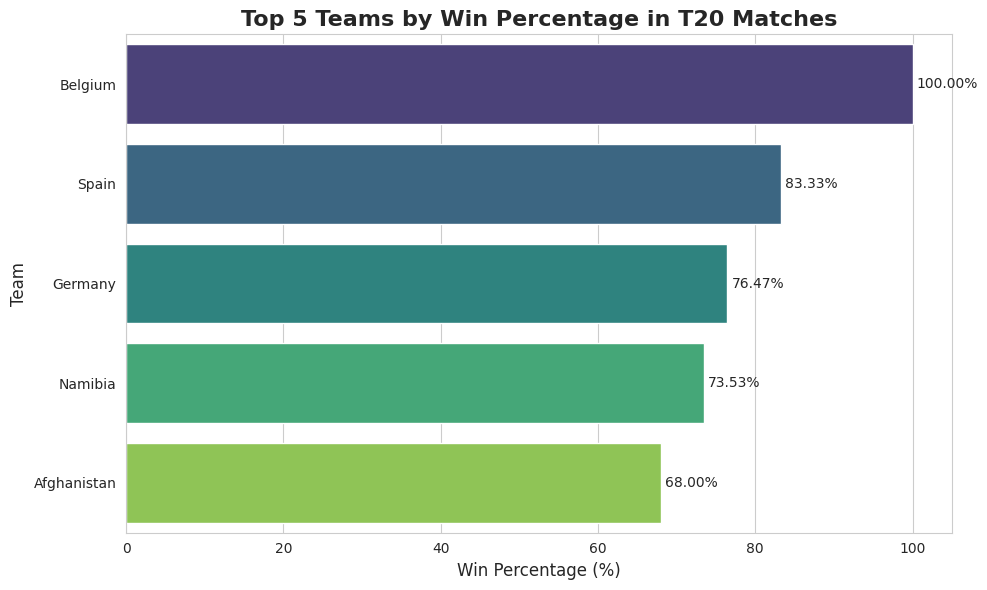

In [ ]:
plt.figure(figsize=(10,6))

sns.set_style("whitegrid")

ax = sns.barplot(
    data=top5,
    x="Win Percentage",
    y="Team",
    palette="viridis"
)

# add title
plt.title("Top 5 Teams by Win Percentage in T20 Matches", fontsize=16, weight='bold')

# axis labels
plt.xlabel("Win Percentage (%)", fontsize=12)
plt.ylabel("Team", fontsize=12)

# add values on bars
for i, v in enumerate(top5["Win Percentage"]):
    ax.text(v + 0.5, i, f"{v:.2f}%", va='center')

plt.tight_layout()

plt.show()

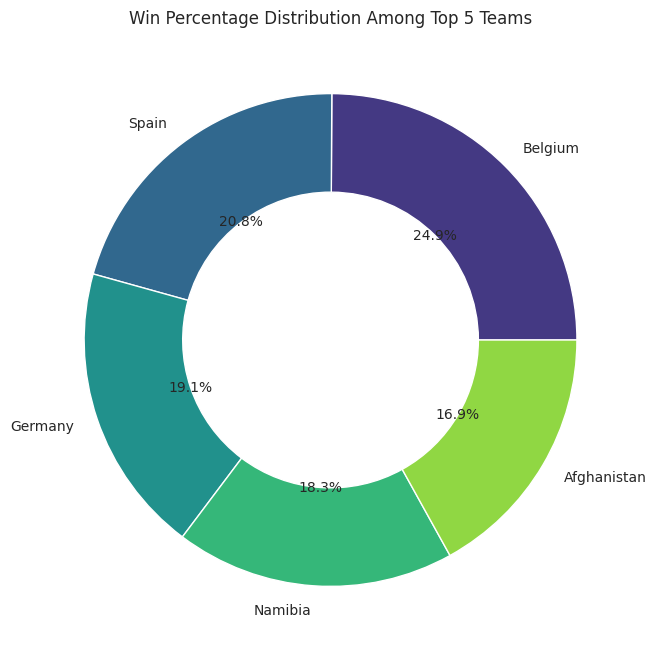

In [ ]:
plt.figure(figsize=(8,8))

colors = sns.color_palette("viridis", len(top5))

plt.pie(
    top5["Win Percentage"],
    labels=top5["Team"],
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops={'width':0.4}
)

plt.title("Win Percentage Distribution Among Top 5 Teams")

plt.show()

/tmp/ipykernel_325/1740362434.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


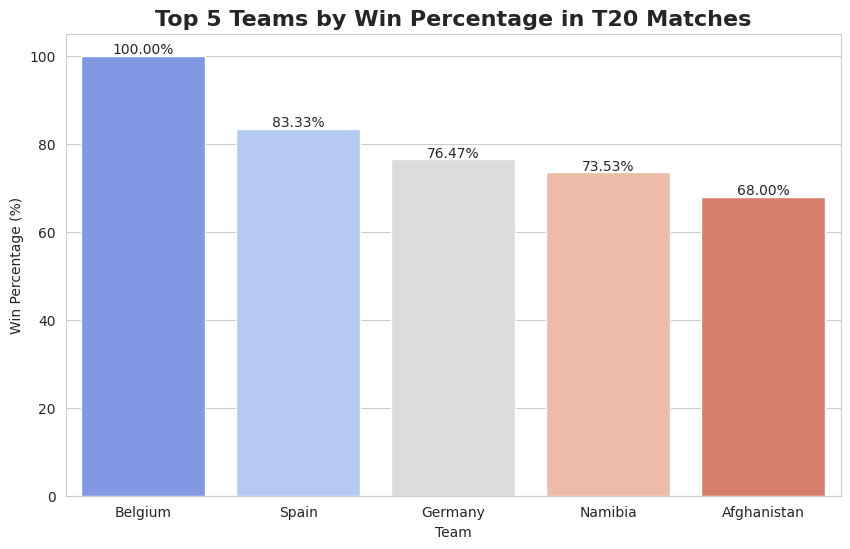

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top5,
    x="Team",
    y="Win Percentage",
    palette="coolwarm"
)

plt.title("Top 5 Teams by Win Percentage in T20 Matches", fontsize=16, weight='bold')
plt.xlabel("Team")
plt.ylabel("Win Percentage (%)")

for i, v in enumerate(top5["Win Percentage"]):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.show()

Write a function to get the scorecard of each match. This function would take the innings value as argument and return two scorecard dataframes each for one team as shown below. So the first dataframe would contain the top 4 scorers of the team who batted first and the top 4 bowlers of the opponent team. And the second dataframe would contain the top 4 scorers of the team who batted second and the top 4 bowlers of the opponent team.

In [ ]:
def get_scorecard(innings):

    bat_first = {}
    bat_second = {}
    bowl_first = {}
    bowl_second = {}

    # first innings
    first_deliveries = innings[0]['1st innings']['deliveries']

    for delivery in first_deliveries:
        ball = list(delivery.values())[0]

        batter = ball['batsman']
        bowler = ball['bowler']
        runs = ball['runs']['batsman']

        bat_first[batter] = bat_first.get(batter, 0) + runs
        bowl_second[bowler] = bowl_second.get(bowler, 0) + runs


    # second innings
    second_deliveries = innings[1]['2nd innings']['deliveries']

    for delivery in second_deliveries:
        ball = list(delivery.values())[0]

        batter = ball['batsman']
        bowler = ball['bowler']
        runs = ball['runs']['batsman']

        bat_second[batter] = bat_second.get(batter, 0) + runs
        bowl_first[bowler] = bowl_first.get(bowler, 0) + runs


    # create scorecard tables
    bat_df1 = pd.DataFrame(bat_first.items(), columns=['Batsman', 'Runs']) \
                .sort_values(by='Runs', ascending=False).head(4)

    bowl_df1 = pd.DataFrame(bowl_second.items(), columns=['Bowler', 'Runs Conceded']) \
                .sort_values(by='Runs Conceded').head(4)

    bat_df2 = pd.DataFrame(bat_second.items(), columns=['Batsman', 'Runs']) \
                .sort_values(by='Runs', ascending=False).head(4)

    bowl_df2 = pd.DataFrame(bowl_first.items(), columns=['Bowler', 'Runs Conceded']) \
                .sort_values(by='Runs Conceded').head(4)


    scorecard1 = pd.concat([bat_df1, bowl_df1], axis=1)
    scorecard2 = pd.concat([bat_df2, bowl_df2], axis=1)

    return scorecard1, scorecard2

In [ ]:
import ast

df['innings'] = df['innings'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [ ]:
score1, score2 = get_scorecard(df['innings'][0])

score1

,Batsman,Runs,Bowler,Runs Conceded
0,AJ Finch,43.0,SL Malinga,28.0
1,M Klinger,38.0,NaN,NaN
2,TM Head,31.0,NaN,NaN
4,AJ Turner,18.0,PADLR Sandakan,30.0
5,NaN,NaN,DAS Gunaratne,11.0
3,NaN,NaN,S Prasanna,22.0


/tmp/ipykernel_325/2509658321.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


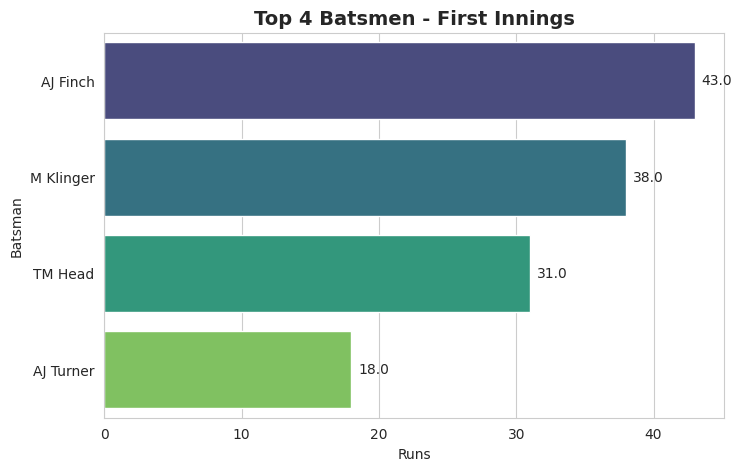

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=score1,
    x="Runs",
    y="Batsman",
    palette="viridis"
)

for i, v in enumerate(score1["Runs"]):
    ax.text(v + 0.5, i, str(v), va="center")

plt.title("Top 4 Batsmen - First Innings", fontsize=14, weight="bold")

plt.show()

In [ ]:
score2

,Batsman,Runs,Bowler,Runs Conceded
3,DAS Gunaratne,52.0,NaN,NaN
2,EMDY Munaweera,44.0,JP Faulkner,26.0
0,N Dickwella,30.0,PJ Cummins,29.0
4,TAM Siriwardana,15.0,A Zampa,26.0
5,NaN,NaN,AJ Turner,12.0


/tmp/ipykernel_325/727399148.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


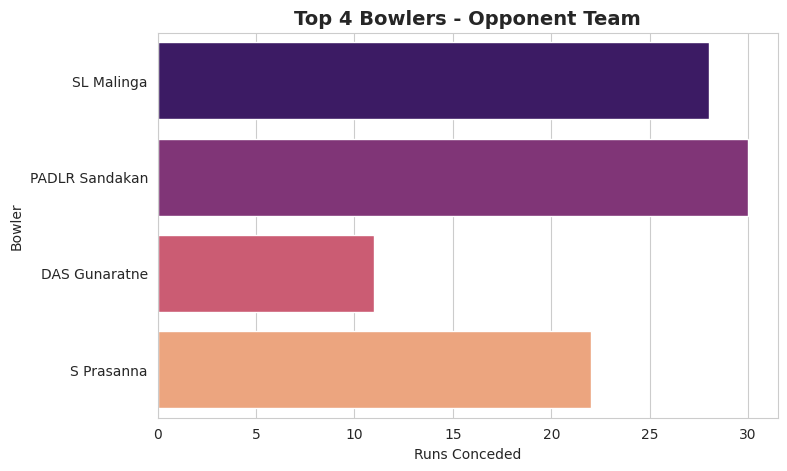

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=score1,
    x="Runs Conceded",
    y="Bowler",
    palette="magma"
)

plt.title("Top 4 Bowlers - Opponent Team", fontsize=14, weight="bold")
plt.xlabel("Runs Conceded")
plt.ylabel("Bowler")

plt.show()